# a. Lakukan Exploratory Data Analysis (EDA) untuk memahami dan mengidentifikasi masalah pada dataset anda. Lakukan pre-processing pada dataset anda sesuai dengan hasil EDA anda, termasuk memisahkan dataset anda menjadi train, val, dan test dengan proporsi 70:10:20.

# Pemuatan Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import itertools
from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2026-04-23 20:01:20.551301: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776974480.949916      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776974481.057926      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776974482.068757      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776974482.068796      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776974482.068799      55 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_parquet('/kaggle/input/datasets/richiedarrian/data-penjualan-mobil-bekas/1B.parquet')
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


Deskripsi tiap kolom berdasarkan makna nama dan contoh datanya:
- Sales_ID: pengidentifikasi unik untuk setiap transaksi penjualan.
- name: merek mobil.
- year: tahun pembuatan mobil.
- selling_price: harga saat mobil terjual (USD).
- km_driven: total kilometer yang telah ditempuh mobil.
- Region: wilayah geografis tempat penjualan terjadi.
- State or Province: negara bagian atau provinsi tempat penjualan terjadi.
- City: kota tempat penjualan berlangsung.
- fuel: jenis bahan bakar yang digunakan mobil (misalnya Petrol, Diesel).
- seller_type: jenis penjual (misalnya Individual, Dealer).
- transmission: jenis transmisi pada mobil (misalnya Manual, Automatic).
- owner: jumlah pemilik sebelumnya dari mobil.
- mileage: efisiensi bahan bakar mobil.
- engine: kapasitas mesin mobil.
- max_power: daya maksimum yang dihasilkan mesin mobil.
- torque: torsi yang dihasilkan oleh mesin mobil.
- seats: kapasitas tempat duduk mobil.
- sold: menunjukkan apakah mobil terjual ('Y' untuk Ya, 'N' untuk Tidak).

# Exploratory Data Analysis (EDA) & Preprocessing

## .info()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   object 
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   object 
 6   State or Province  2000 non-null   object 
 7   City               2000 non-null   object 
 8   fuel               2000 non-null   object 
 9   seller_type        2000 non-null   object 
 10  transmission       2000 non-null   object 
 11  owner              2000 non-null   object 
 12  mileage            2000 non-null   object 
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   object 
 16  seats              2000 

Kolom `selling_price` adalah target prediksinya, tetapi terdapat nilai yang hilang (*missing values*) di dalamnya. Jika data dengan nilai hilang ini tetap digunakan menggunakan nilai imputasi, hal tersebut dapat menyesatkan model dan menghasilkan prediksi yang tidak akurat sehingga lebih baik baris dengan nilai hilang tersebut dihilangkan.

In [4]:
df = df.dropna(subset=['selling_price'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           1998 non-null   int64  
 1   name               1998 non-null   object 
 2   year               1998 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          1998 non-null   int64  
 5   Region             1998 non-null   object 
 6   State or Province  1998 non-null   object 
 7   City               1998 non-null   object 
 8   fuel               1998 non-null   object 
 9   seller_type        1998 non-null   object 
 10  transmission       1998 non-null   object 
 11  owner              1998 non-null   object 
 12  mileage            1998 non-null   object 
 13  engine             1998 non-null   int64  
 14  max_power          1998 non-null   float64
 15  torque             1998 non-null   object 
 16  seats              1998 non-n

Kolom target berhasil dibersihkan.

## .describe for object

In [5]:
df.describe(include=['object'])

,name,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,torque,sold
count,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998
unique,27,5,49,935,4,3,3,5,305,292,2
top,Maruti,Central,California,New York City,Diesel,Individual,Manual,First_Owner,18.9,190Nm@ 2000rpm,N
freq,578,605,222,58,1082,1631,1741,1339,61,127,1487


Ada beberapa insight yang bisa diperoleh dari hasil .describe(include='object') tersebut:
- **Kolom `City` memiliki kardinalitas yang cukup tinggi** yang berpotensi menyebabkan overfitting jika langsung digunakan pada model deep learning tertentu. Namun, saya setuju bahwa informasi kota bisa jadi relevan dan penting untuk memprediksi harga (bisa saja tiap kota memiliki harga tersendiri untuk tiap mobil), dan saya bisa mengatasinya dengan representasi yang tepat (misalnya, menggunakan dense layer) agar model tetap dapat mempelajari pola dari fitur ini.
- **Saat ini, kolom `mileage` terdeteksi sebagai tipe data object** padahal seharusnya berupa angka (float). Ini mengindikasikan adanya data yang aneh di dalamnya. Untuk memastikan konsistensi data, perlu dilakukan penelusuran lebih lanjut untuk mengidentifikasi dan membersihkan anomali ini agar dapat dikonversi menjadi tipe numerik yang benar, dan model deep learning bisa mengekstrasikan pola dengan lebih efektif.
- **Kolom `torque` saat ini dalam format teks yang menggabungkan nilai torsi dan putaran mesin (RPM)**. Sebaiknya kolom ini dipecah menjadi dua kolom numerik yang terpisah: satu untuk nilai torsi (`torque_value`) dan satu lagi untuk putaran mesin saat torsi tersebut tercapai (`torque_rpm`). Dengan demikian, model deep learning dapat memanfaatkan informasi numerik ini secara lebih efektif untuk mempelajari pola tersembunyi yang mungkin ada kaitannya dengan harga jual, dibandingkan jika model hanya menganggapnya sebagai representasi teks.

In [6]:
temp_mileage_numeric = pd.to_numeric(df['mileage'], errors='coerce')
non_numeric_mileage = df[temp_mileage_numeric.isna()]['mileage'].unique()
display(pd.Series(non_numeric_mileage, name='Non-numeric mileage entries'))

0     nan
1    15,3
2    23,1
Name: Non-numeric mileage entries, dtype: object

Bisa dilihat bahwa terdapat dua jenis masalah pada kolom `mileage`:
- **Ada angka yang menggunakan koma (,) untuk melambangkan angka desimal**, padahal pada umumnya seharusnya menggunakan titik (.) ketika manipulasi data di Pandas. Oleh karena itu, setiap koma di situ harus diubah ke titik agar bisa dibaca oleh Pandas dengan benar.
- **Ada string yang menyatakan missing values berupa 'nan'**. Ini sudah jelas harus di-handle dengan mengubahnya langsung ke tipe data missing values (NaN)

In [7]:
df['mileage'] = df['mileage'].astype(str).str.replace(',', '.', regex=False)
df['mileage'] = df['mileage'].replace('nan', np.nan)
df['mileage'] = pd.to_numeric(df['mileage'])

In [8]:
temp_mileage_numeric = pd.to_numeric(df['mileage'], errors='coerce')
non_numeric_mileage = df[temp_mileage_numeric.isna()]['mileage'].unique()
display(pd.Series(non_numeric_mileage, name='Non-numeric mileage entries'))

0   NaN
Name: Non-numeric mileage entries, dtype: float64

Bisa dilihat bahwa satu-satunya nilai yang tersisa selain nilai numerik adalah NaN yang merepresentasikan missing values. Missing values akan diselesaikan di akhir-akhir setelah semua missing values tersembunyi sudah ditangani.

In [9]:
df['torque'].head(20).to_frame().T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
torque,114Nm@ 4000rpm,330Nm@ 1800rpm,110Nm@ 4800rpm,200Nm@ 1750rpm,115Nm@ 4000rpm,360Nm@ 2000rpm,"145@ 4,100(kgm@ rpm)",112Nm@ 4000rpm,200Nm@ 1750rpm,72Nm@ 4386rpm,90Nm@ 3500rpm,113.75nm@ 4000rpm,110Nm@ 3750rpm,200Nm@ 1400-2200rpm,69Nm@ 3500rpm,190Nm@ 2000rpm,72Nm@ 4386rpm,77Nm@ 3500rpm,85Nm@ 3000rpm,205Nm@ 1750-3250rpm


In [10]:
 # menghilangkan semua angka
df['torque_pattern'] = df['torque'].str.replace(r'\d+\.?\d*', '', regex=True)

In [11]:
df['torque_pattern'].value_counts()

torque_pattern
Nm@ rpm            1161
Nm@ -rpm            595
@ ,(kgm@ rpm)        68
nm@ rpm              32
nm@ -rpm             28
@ -(kgm@ rpm)        26
@ ,-,(kgm@ rpm)      13
Nm                   12
 Nm at -rpm          11
 kgm at -rpm          9
 Nm at - rpm          7
Nm at  rpm            6
 kgm at , rpm         4
 KGM at - RPM         4
 Nm at   rpm          3
Nm at - rpm           3
@ (kgm@ rpm)          3
Nm@ +/-rpm            2
 Nm at  rpm           2
kgm@ rpm              2
  Nm at   rpm         1
 Nm at rpm            1
 Nm at  rpm           1
Nm@                   1
Nm@ -                 1
Nm@ ,rpm              1
NM@ rpm               1
Name: count, dtype: int64

Ada terlalu banyak variasi string yang terdapat pada satu kolom itu sehingga harus dilakukan unifikasi.

In [12]:
display(df[df['torque_pattern'] == '@ ,-,(kgm@ rpm)']['torque'].value_counts().to_frame())

,count
torque,
"24@ 1,900-2,750(kgm@ rpm)",9
"28.3@ 1,700-2,200(kgm@ rpm)",2
"35.7@ 1,750-3,000(kgm@ rpm)",1
"25@ 1,800-2,800(kgm@ rpm)",1


In [13]:
display(df[df['torque_pattern'] == 'Nm@ +/-rpm']['torque'].value_counts().to_frame())

,count
torque,
51Nm@ 4000+/-500rpm,2


Masalah-masalah yang ditemukan pada kolom `torque` adalah sebagai berikut.
- **Satuan yang berbeda**. Terdapat dua jenis satuan torsi yang digunakan, yaitu kgm (kilogram-meter) dan Nm (Newton-meter). Untuk konsistensi pemaknaan oleh model, kgm perlu dikonversi ke Nm.
- **Format RPM bervariasi**. Kolom RPM dapat memiliki format rentang (misalnya, 1900-2750rpm), hanya satu angka (misalnya, 4000rpm), atau rentang toleransi (misalnya, 4000+/-500rpm), yang semuanya menunjukkan putaran mesin.
- **Penempatan satuan**. Satuan torsi (Nm atau kgm) terkadang terletak tepat di sebelah nilai numeriknya, dan di lain waktu dikumpulkan di bagian akhir string bersama dengan satuan RPM.
- **Pemisah ribuan**. Angka-angka terkadang menggunakan koma (,) sebagai pemisah ribuan, yang perlu dihilangkan agar nilai numerik dapat diekstraksi dengan benar dan tidak disalahartikan sebagai angka yang terpisah.
- **Penggunaan Tanda 'at'**. Terkadang penghubung antara nilai torsi dan RPM menggunakan kata 'at' (misalnya, Nm at rpm), sementara di lain waktu menggunakan simbol '@' (misalnya, Nm@ rpm).
- **Perbedaan huruf besar/kecil (casing)**. Penulisan satuan dapat bervariasi dalam penggunaan huruf besar dan kecil (misalnya, KGM, kgm, Nm, atau nm) sehingga perlu dinormalisasi agar konsisten.

Untuk mempermudah proses, semua langkah pembersihan dan ekstraksi kolom `torque` akan digabungkan menjadi satu *code cell*:

In [ ]:
# 1. Melakukan normalisasi teks pada kolom 'torque'
df['torque_clean'] = (
    df['torque']
    .str.lower() # Menyatukan penulisan satuan menjadi huruf kecil semua
    .str.replace(',', '', regex=False) # Menghilangkan koma sebagai pemisah ribuan
    .str.replace(r'\bat\b', '@', regex=True) # Konversi 'at' menjadi '@'
    .str.replace(r'\s+', '', regex=True) # Menghilangkan semua whitespace
)

# 2. Merapikan format satuan (misalnya mengubah 25@1800-2800(kgm@rpm) -> 25kgm@1800-2800rpm)
df['torque_clean'] = df['torque_clean'].str.replace(r'(\d+)@([\d-]+)\(kgm@rpm\)', r'\1kgm@\2rpm',regex=True)

# 3. Ekstraksi nilai torsi dan satuan (nm atau kgm)
df['torque_value'] = df['torque_clean'].str.extract(r'(\d+\.?\d*)').astype(float)
df['torque_unit'] = df['torque_clean'].str.extract(r'(nm|kgm)')

# 4. Ekstraksi RPM (min dan max) yang memiliki tiga variasi:
# a. Satu nilai = 50nm@1000rpm
rpm_single = df['torque_clean'].str.extract(r'@(\d+)rpm')
# b. Rentang nilai = 25kgm@1800-2800rpm
rpm_range = df['torque_clean'].str.extract(r'@(\d+)-(\d+)rpm')
# c. Satu nilai dengan toleransi = 51Nm@ 4000+/-500rpm
rpm_tol = df['torque_clean'].str.extract(r'@(\d+)\+/-?(\d+)rpm')
# Konversi ke float
rpm_range = rpm_range.astype(float)
rpm_tol = rpm_tol.astype(float)
rpm_single = rpm_single.astype(float)
# Menghitung rpm_min & rpm_max
df['rpm_min'] = rpm_range[0].fillna(rpm_tol[0] - rpm_tol[1]).fillna(rpm_single[0])
df['rpm_max'] = rpm_range[1].fillna(rpm_tol[0] + rpm_tol[1]).fillna(rpm_single[0])

# 5. Konversi 'kgm' ke 'nm'
conversion_factor = 9.8067
df.loc[df['torque_unit'] == 'kgm', 'torque_value'] *= conversion_factor
df.loc[df['torque_unit'] == 'kgm', 'torque_unit'] = 'nm'

# 6. Menghapus kolom-kolom sementara
df = df.drop(columns=['torque_clean', 'torque_unit'], errors='ignore')

Berikut adalah ringkasan setiap langkah pembersihan dan rekayasa fitur pada kolom `torque`:

1.  **Normalisasi teks pada kolom 'torque'**. Menormalisasi teks dengan mengubah seluruh karakter menjadi huruf kecil, menghapus tanda koma sebagai pemisah ribuan, mengonversi kata "at" menjadi simbol @, serta menghilangkan seluruh whitespace agar format menjadi konsisten dan mudah diproses.
2.  **Merapikan format satuan**. Menyesuaikan format data yang tidak konsisten, khususnya pola seperti 25@1800-2800(kgm@rpm) menjadi 25kgm@1800-2800rpm agar seragam dan dapat diekstraksi menggunakan regex.
3.  **Ekstraksi nilai torsi dan satuan (Nm atau kgm)**. Mengekstraksi nilai numerik torsi ke dalam kolom `torque_value` dan satuannya (nm atau kgm) ke dalam kolom `torque_unit` untuk memisahkan informasi numerik dan kategorikal.
4.  **Ekstraksi RPM (min dan max)**. Mengekstraksi nilai RPM berdasarkan tiga kemungkinan format:
    - Nilai tunggal (misalnya 1000rpm)
    - Rentang (misalnya 1800-2800rpm)
    - Nilai dengan toleransi (misalnya 4000+/-500rpm) yang dikonversi menjadi rentang dengan:
        - `rpm_min = nilai - toleransi`
        - `rpm_max = nilai + toleransi`
5.  **Konversi 'kgm' ke 'Nm'**. Mengonversi seluruh nilai torsi dari kgm ke Nm menggunakan faktor konversi 9.8067 untuk memastikan konsistensi satuan dalam analisis berdasarkan https://convertlive.com/id/u/mengkonversi/kilogram-force-meter/ke/newton-meter-243#1
6.  **Menghapus kolom-kolom sementara**. Menghapus kolom `torque_clean` dan `torque_unit` karena seluruh informasi penting telah diekstraksi ke dalam fitur baru (`torque_value`, `rpm_min`, dan `rpm_max`).

In [15]:
# Tampilkan beberapa baris untuk verifikasi
display(df[['torque', 'torque_value', 'rpm_min', 'rpm_max']].head())

,torque,torque_value,rpm_min,rpm_max
0,114Nm@ 4000rpm,114.0,4000.0,4000.0
1,330Nm@ 1800rpm,330.0,1800.0,1800.0
2,110Nm@ 4800rpm,110.0,4800.0,4800.0
3,200Nm@ 1750rpm,200.0,1750.0,1750.0
4,115Nm@ 4000rpm,115.0,4000.0,4000.0


In [16]:
display(
    df.loc[
        df['torque_pattern'] == 'Nm@ -rpm',
        ['torque', 'torque_value', 'rpm_min', 'rpm_max']
    ]
)

,torque,torque_value,rpm_min,rpm_max
13,200Nm@ 1400-2200rpm,200.0,1400.0,2200.0
19,205Nm@ 1750-3250rpm,205.0,1750.0,3250.0
20,250Nm@ 1500-2500rpm,250.0,1500.0,2500.0
29,343Nm@ 1400-3400rpm,343.0,1400.0,3400.0
33,195Nm@ 1400-2200rpm,195.0,1400.0,2200.0
...,...,...,...,...
1988,330Nm@ 1600-2800rpm,330.0,1600.0,2800.0
1992,202Nm@ 3600-5200rpm,202.0,3600.0,5200.0
1993,280Nm@ 1800-2800rpm,280.0,1800.0,2800.0
1995,171.6Nm@ 1500-4000rpm,171.6,1500.0,4000.0


In [17]:
display(
    df.loc[
        df['torque_pattern'] == 'Nm@ +/-rpm',
        ['torque', 'torque_value', 'rpm_min', 'rpm_max']
    ]
)

,torque,torque_value,rpm_min,rpm_max
306,51Nm@ 4000+/-500rpm,51.0,3500.0,4500.0
396,51Nm@ 4000+/-500rpm,51.0,3500.0,4500.0


In [18]:
display(
    df.loc[
        df['torque_pattern'] == '@ ,-,(kgm@ rpm)',
        ['torque', 'torque_value', 'rpm_min', 'rpm_max']
    ]
)

,torque,torque_value,rpm_min,rpm_max
26,"24@ 1,900-2,750(kgm@ rpm)",235.36080,1900.0,2750.0
204,"24@ 1,900-2,750(kgm@ rpm)",235.36080,1900.0,2750.0
534,"24@ 1,900-2,750(kgm@ rpm)",235.36080,1900.0,2750.0
669,"24@ 1,900-2,750(kgm@ rpm)",235.36080,1900.0,2750.0
733,"24@ 1,900-2,750(kgm@ rpm)",235.36080,1900.0,2750.0
793,"28.3@ 1,700-2,200(kgm@ rpm)",277.52961,1700.0,2200.0
1037,"35.7@ 1,750-3,000(kgm@ rpm)",350.09919,1750.0,3000.0
1127,"24@ 1,900-2,750(kgm@ rpm)",235.36080,1900.0,2750.0
1248,"28.3@ 1,700-2,200(kgm@ rpm)",277.52961,1700.0,2200.0
1645,"25@ 1,800-2,800(kgm@ rpm)",245.16750,1800.0,2800.0


Karena setiap angka relevan dari kolom `torque` sudah berhasil diekstraksi dan `torque_pattern` sudah tidak diperlukan juga, maka bisa langsung saja dihapus untuk mengurangi kompleksitas data yang harus ditangani.

In [19]:
df = df.drop(columns=['torque', 'torque_pattern'])

In [20]:
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_value,rpm_min,rpm_max
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.60,1197,85.8,5,Y,114.0,4000.0,4000.0
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.10,2499,141.0,7,N,330.0,1800.0,1800.0
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.50,1199,88.7,5,N,110.0,4800.0,4800.0
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,5,N,200.0,1750.0,1750.0
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.40,1197,83.1,5,Y,115.0,4000.0,4000.0


## .describe excluding object

In [21]:
df.describe(exclude='object')

,Sales_ID,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_value,rpm_min,rpm_max
count,1998.000000,1998.000000,1998.000000,1998.000000,1996.000000,1998.000000,1998.000000,1998.000000,1998.000000,1984.000000,1984.000000
mean,4092.906907,2014.544044,6500.861947,68835.103604,19.430426,1463.348849,91.882530,5.408408,181.330900,2685.300403,3085.809476
std,2365.079239,22.605272,8322.011983,50114.126435,3.960921,500.953729,36.142477,0.950118,111.542897,1110.001639,892.299040
min,1.000000,1999.000000,350.000000,0.000000,0.000000,624.000000,-100.000000,4.000000,48.000000,1000.000000,1400.000000
25%,2008.500000,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000,111.800000,1750.000000,2500.000000
50%,4070.500000,2015.000000,4500.000000,60000.000000,19.330000,1248.000000,82.000000,5.000000,170.000000,2000.000000,3000.000000
75%,6196.750000,2017.000000,6750.000000,90000.000000,22.320000,1582.000000,102.000000,5.000000,213.000000,4000.000000,4000.000000
max,8127.000000,3011.000000,100000.000000,475000.000000,42.000000,3604.000000,400.000000,14.000000,1421.971500,5000.000000,5300.000000


Terdapat beberapa anomali data yang ditemukan berdasarkan rangkuman statistik di atas:
- Kolom `year` tidak mungkin melebihi tahun 2026 (terdapat nilai 3011 sebagai nilai max). Semua nilai di atas 2026 akan dijadikan *missing values*.
- Kolom `max_power` tidak mungkin negatif atau nol, jadi semua nilai yang kurang dari atau sama dengan 0 akan dijadikan missing value.

In [22]:
# 1. Kolom `year` tidak mungkin melebihi 2026
df.loc[df['year'] > 2026, 'year'] = np.nan

# 2. Kolom `max_power` tidak mungkin negatif atau nol
df.loc[df['max_power'] <= 0, 'max_power'] = np.nan

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           1998 non-null   int64  
 1   name               1998 non-null   object 
 2   year               1997 non-null   float64
 3   selling_price      1998 non-null   float64
 4   km_driven          1998 non-null   int64  
 5   Region             1998 non-null   object 
 6   State or Province  1998 non-null   object 
 7   City               1998 non-null   object 
 8   fuel               1998 non-null   object 
 9   seller_type        1998 non-null   object 
 10  transmission       1998 non-null   object 
 11  owner              1998 non-null   object 
 12  mileage            1996 non-null   float64
 13  engine             1998 non-null   int64  
 14  max_power          1997 non-null   float64
 15  seats              1998 non-null   int64  
 16  sold               1998 non-n

In [24]:
df.describe(exclude='object')

,Sales_ID,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_value,rpm_min,rpm_max
count,1998.000000,1997.000000,1998.000000,1998.000000,1996.000000,1998.000000,1997.000000,1998.000000,1998.000000,1984.000000,1984.000000
mean,4092.906907,2014.045068,6500.861947,68835.103604,19.430426,1463.348849,91.978615,5.408408,181.330900,2685.300403,3085.809476
std,2365.079239,3.680770,8322.011983,50114.126435,3.960921,500.953729,35.895369,0.950118,111.542897,1110.001639,892.299040
min,1.000000,1999.000000,350.000000,0.000000,0.000000,624.000000,32.800000,4.000000,48.000000,1000.000000,1400.000000
25%,2008.500000,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000,111.800000,1750.000000,2500.000000
50%,4070.500000,2015.000000,4500.000000,60000.000000,19.330000,1248.000000,82.000000,5.000000,170.000000,2000.000000,3000.000000
75%,6196.750000,2017.000000,6750.000000,90000.000000,22.320000,1582.000000,102.000000,5.000000,213.000000,4000.000000,4000.000000
max,8127.000000,2020.000000,100000.000000,475000.000000,42.000000,3604.000000,400.000000,14.000000,1421.971500,5000.000000,5300.000000


Tidak ada anomali data lainnya yang tampak di sini.

## Categorical Checks

In [25]:
categorical_cols = df.select_dtypes(include='object').columns

pd.set_option('display.max_rows', None)
for col in categorical_cols:
    print(f"Value counts for column '{col}':")
    display(df[col].value_counts().to_frame())
    print("\n" + "-"*50 + "\n")
pd.set_option('display.max_rows', 50)

Value counts for column 'name':


,count
name,
Maruti,578
Hyundai,360
Mahindra,184
Tata,184
Toyota,122
Ford,115
Honda,114
Renault,54
Chevrolet,49



--------------------------------------------------

Value counts for column 'Region':


,count
Region,
Central,605
West,507
East,483
South,401
N/A,2



--------------------------------------------------

Value counts for column 'State or Province':


...


--------------------------------------------------

Value counts for column 'owner':


,count
owner,
First_Owner,1339
Second_Owner,488
Third_Owner,118
Fourth_Above_Owner,51
Test_Drive_Car,2



--------------------------------------------------

Value counts for column 'sold':


,count
sold,
N,1487
Y,511



--------------------------------------------------



Beberapa masalah pada _missing values_ ditemukan untuk kolom-kolom kategorikal:
- Kolom `Region` memiliki _string_ yang melambangkan _missing values_ bernama 'N/A'.
- Kolom `transmission` memiliki _missing values_ berupa _empty string_.
Kedua bentuk _missing values_ tersebut akan disatukan dalam bentuk `np.nan` pandas untuk konsistensi.

Selain itu, `City` memiliki kardinalitas yang terlalu tinggi dengan hampir setiap kategorinya hanya memiliki 1-3 kemunculan. Hal ini membuat model deep learning kesulitan untuk generalisasi sehingga lebih baik dibuang saja.

In [26]:
# 1. Handle missing values di kolom 'Region'
df['Region'] = df['Region'].replace('N/A', np.nan)

# 2. Handle missing values di 'transmission'
df['transmission'] = df['transmission'].replace('', np.nan)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           1998 non-null   int64  
 1   name               1998 non-null   object 
 2   year               1997 non-null   float64
 3   selling_price      1998 non-null   float64
 4   km_driven          1998 non-null   int64  
 5   Region             1996 non-null   object 
 6   State or Province  1998 non-null   object 
 7   City               1998 non-null   object 
 8   fuel               1998 non-null   object 
 9   seller_type        1998 non-null   object 
 10  transmission       1996 non-null   object 
 11  owner              1998 non-null   object 
 12  mileage            1996 non-null   float64
 13  engine             1998 non-null   int64  
 14  max_power          1997 non-null   float64
 15  seats              1998 non-null   int64  
 16  sold               1998 non-n

In [28]:
df = df.drop(columns=['City'])

In [29]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Value counts for column '{col}':")
    display(df[col].value_counts().to_frame())
    print("\n" + "-"*50 + "\n")

Value counts for column 'name':


,count
name,
Maruti,578
Hyundai,360
Mahindra,184
Tata,184
Toyota,122
Ford,115
Honda,114
Renault,54
Chevrolet,49



--------------------------------------------------

Value counts for column 'Region':


,count
Region,
Central,605
West,507
East,483
South,401



--------------------------------------------------

Value counts for column 'State or Province':


...


--------------------------------------------------

Value counts for column 'owner':


,count
owner,
First_Owner,1339
Second_Owner,488
Third_Owner,118
Fourth_Above_Owner,51
Test_Drive_Car,2



--------------------------------------------------

Value counts for column 'sold':


,count
sold,
N,1487
Y,511



--------------------------------------------------



Tidak ada masalah-masalah data lainnya yang tampak di kolom-kolom kategorikal lainnya.

## Numerical Checks

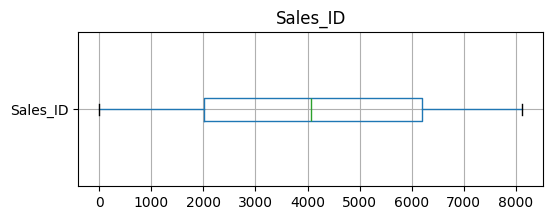

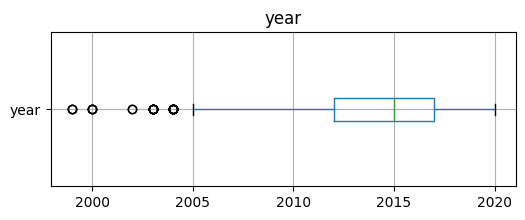

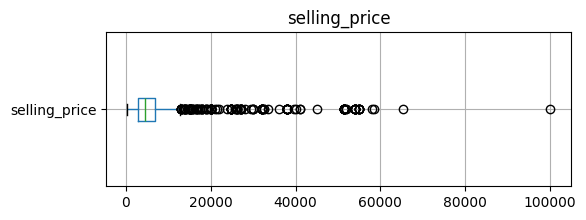

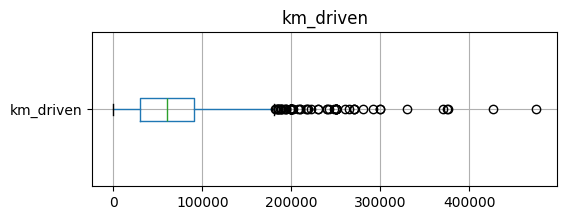

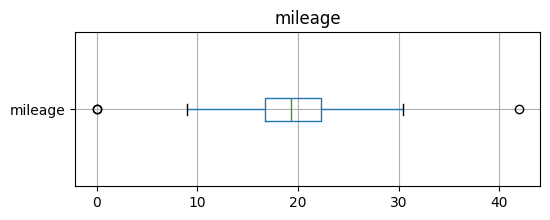

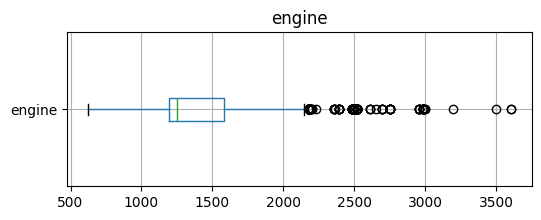

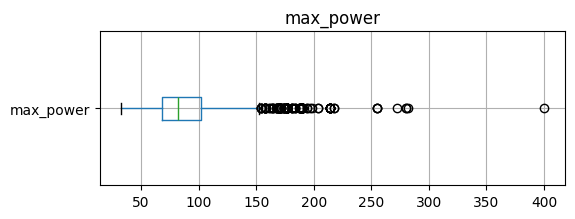

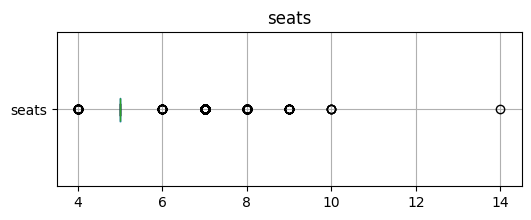

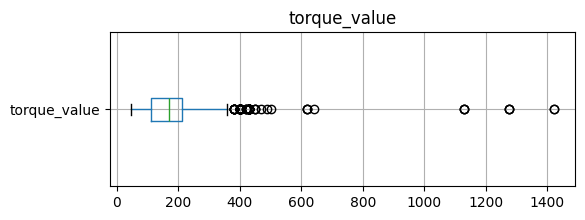

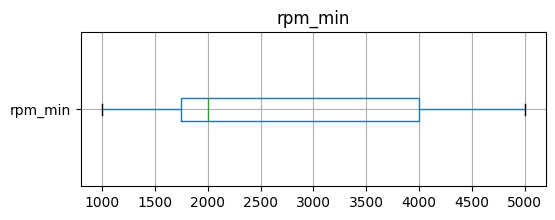

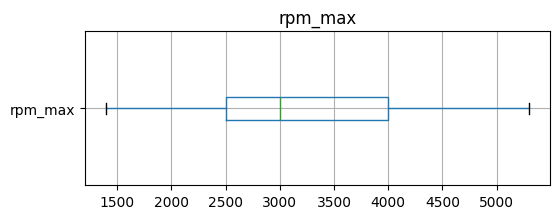

,Sales_ID,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_value,rpm_min,rpm_max
min,1,1999.0,350.0,0,0.0,624,32.8,4,48.0000,1000.0,1400.0
max,8127,2020.0,100000.0,475000,42.0,3604,400.0,14,1421.9715,5000.0,5300.0


In [30]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6, 2))
    df[[col]].boxplot(vert=False)
    plt.title(col)
    plt.show()

df.select_dtypes(include="number").agg(["min", "max"])

Ada beberapa outliers yang kelihatan mencolok, tetapi mereka masih dalam batas yang wajar sehingga akan tetap disimpan dan tidak dibuang.

In [31]:
for col in num_cols:
    vals = df[col].dropna()

    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    outliers = vals[(vals < LB) | (vals > UB)]
    outlier_pct = (len(outliers) / len(vals)) * 100

    skewness = vals.skew()

    print(f"Column: {col}")
    print(f"  Outlier Percentage: {outlier_pct:.2f}%")
    print(f"  Skewness: {skewness:.3f}")
    print("-" * 40)


Column: Sales_ID
  Outlier Percentage: 0.00%
  Skewness: -0.002
----------------------------------------
Column: year
  Outlier Percentage: 1.50%
  Skewness: -0.812
----------------------------------------
Column: selling_price
  Outlier Percentage: 7.21%
  Skewness: 4.421
----------------------------------------
Column: km_driven
  Outlier Percentage: 3.10%
  Skewness: 1.823
----------------------------------------
Column: mileage
  Outlier Percentage: 0.15%
  Skewness: -0.007
----------------------------------------
Column: engine
  Outlier Percentage: 15.17%
  Skewness: 1.124
----------------------------------------
Column: max_power
  Outlier Percentage: 6.76%
  Skewness: 1.781
----------------------------------------
Column: seats
  Outlier Percentage: 20.82%
  Skewness: 2.168
----------------------------------------
Column: torque_value
  Outlier Percentage: 4.40%
  Skewness: 4.201
----------------------------------------
Column: rpm_min
  Outlier Percentage: 0.00%
  Skewness: 0.

Karena hampir semuanya memiliki skewness lebih besar dari 0,5 atau lebih kecil dari -0,5, maka lebih baik setiap fitur di-scaling menggunakan Robust Scaler yang tahan terhadap outliers.

## Missing Values Check

In [32]:
print("Jumlah missing values untuk setiap kolom:")
df.isna().sum()

Jumlah missing values untuk setiap kolom:


Sales_ID              0
name                  0
year                  1
selling_price         0
km_driven             0
Region                2
State or Province     0
fuel                  0
seller_type           0
transmission          2
owner                 0
mileage               2
engine                0
max_power             1
seats                 0
sold                  0
torque_value          0
rpm_min              14
rpm_max              14
dtype: int64

Jumlah missing values di dataset itu cenderung sedikit, tetapi bermasalah untuk model deep learning ketika tidak di-handle karena model tidak bisa mencerna tipe data NaN. Kolom numerikal akan diimputasi dengan median karena cenderung skewed sehingga nilai mean-nya bisa menipu nilai tengah distribusi, dan kolom kategorikal akan diimputasi dengan modus.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           1998 non-null   int64  
 1   name               1998 non-null   object 
 2   year               1997 non-null   float64
 3   selling_price      1998 non-null   float64
 4   km_driven          1998 non-null   int64  
 5   Region             1996 non-null   object 
 6   State or Province  1998 non-null   object 
 7   fuel               1998 non-null   object 
 8   seller_type        1998 non-null   object 
 9   transmission       1996 non-null   object 
 10  owner              1998 non-null   object 
 11  mileage            1996 non-null   float64
 12  engine             1998 non-null   int64  
 13  max_power          1997 non-null   float64
 14  seats              1998 non-null   int64  
 15  sold               1998 non-null   object 
 16  torque_value       1998 non-n

In [34]:
# Pisahkan kolom numerik dan kategorikal
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

# Imputasi numerikal dengan median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
# Imputasi kategorikal dengan modus
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [35]:
print("Jumlah missing values setelah imputasi:")
df.isna().sum()

Jumlah missing values setelah imputasi:


Sales_ID             0
name                 0
year                 0
selling_price        0
km_driven            0
Region               0
State or Province    0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage              0
engine               0
max_power            0
seats                0
sold                 0
torque_value         0
rpm_min              0
rpm_max              0
dtype: int64

## Deduplication Check

In [36]:
print(f"Total deduplikasi: {df.duplicated().sum()}")

Total deduplikasi: 0


Karena tidak ada data yang mengalami deduplikasi (ID sama menunjuk kepada mobil yang sama sehingga menjadi informasi yang redundan), maka kolom ID bisa dihilangkan sebab fungsinya sudah selesai di situ saja.

In [37]:
df.drop(columns=['Sales_ID'], inplace=True)

## Correlation Checks

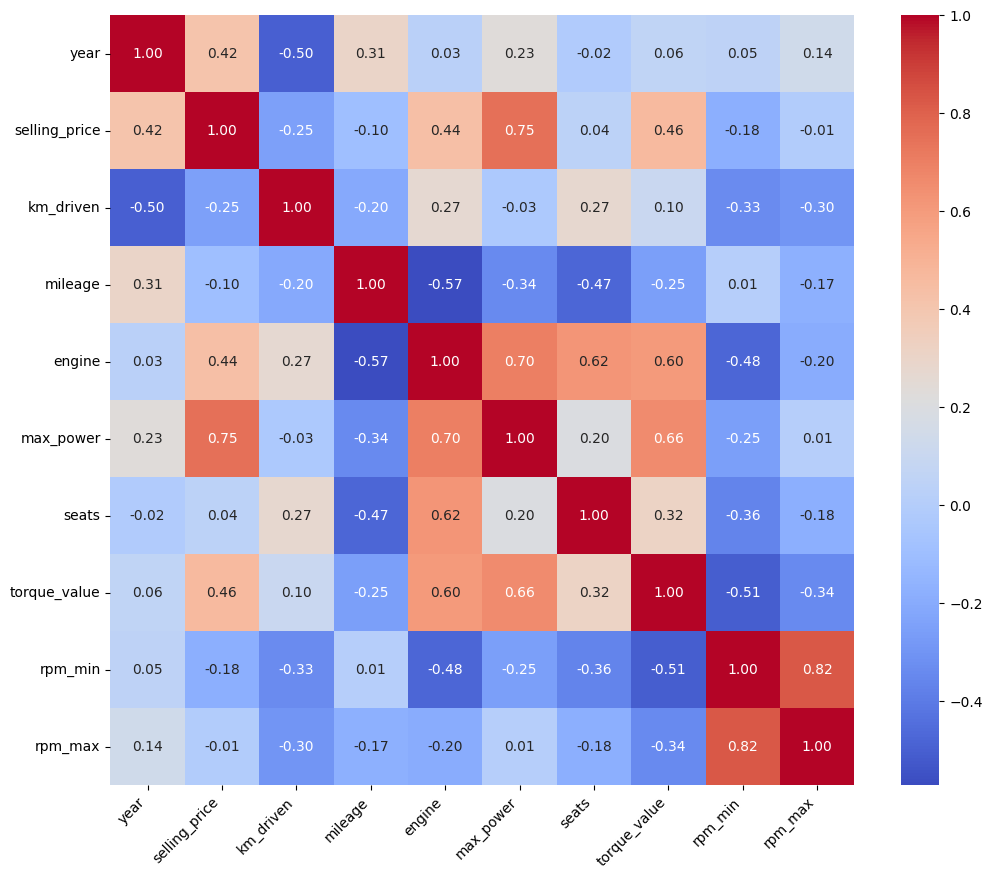

In [38]:
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Sebagian besar fitur-fitur memiliki korelasi yang cukup tinggi, tetapi ada beberapa fitur yang berkorelasi sangat rendah (<= 0.1) dengan `selling_price`, yaitu `seats`, `rpm_max`, dan `mileage`

Berdasarkan pengujian permutasi fitur yang dilakukan pada bagian training di paling bawah, `rpm_max` malah mengurangi performa model dibandingkan tidak menggunakannya, maka rpm_max akan langsung dihapus saja.

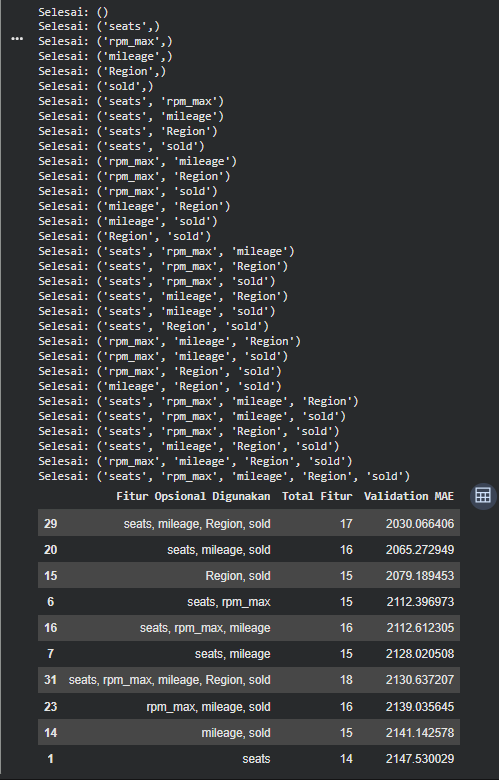

In [39]:
df = df.drop(columns=['rpm_max'])
df.head()

,name,year,selling_price,km_driven,Region,State or Province,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_value,rpm_min
0,Maruti,2013.0,4500.00,41800,South,Florida,Petrol,Individual,Manual,First_Owner,18.60,1197,85.8,5,Y,114.0,4000.0
1,Ford,2004.0,4000.00,93415,East,Massachusetts,Diesel,Dealer,Manual,First_Owner,13.10,2499,141.0,7,N,330.0,1800.0
2,Honda,2017.0,8199.99,12000,South,Arkansas,Petrol,Individual,Manual,First_Owner,17.50,1199,88.7,5,N,110.0,4800.0
3,Maruti,2016.0,6750.00,108000,East,New York,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,5,N,200.0,1750.0
4,Maruti,2019.0,6750.00,5000,Central,Illinois,Petrol,Individual,Automatic,First_Owner,21.40,1197,83.1,5,Y,115.0,4000.0


In [40]:
df.select_dtypes(include=["object"]).columns

Index(['name', 'Region', 'State or Province', 'fuel', 'seller_type',
       'transmission', 'owner', 'sold'],
      dtype='object')

In [41]:
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["int64", "Int64", "float64"]).columns

results = []

for cat_col in cat_cols:
    for num_col in num_cols:
        groups = [df.loc[df[cat_col] == cat, num_col].dropna() for cat in df[cat_col].dropna().unique()]
        if len(groups) > 1 and all(len(g) > 1 for g in groups):
            f_stat, p_value = f_oneway(*groups)
            all_vals = np.concatenate(groups)
            grand_mean = all_vals.mean()
            ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
            ss_total = ((all_vals - grand_mean) ** 2).sum()
            eta_squared = ss_between / ss_total
            results.append({"Categorical": cat_col, "Numerical": num_col, "p_value": p_value, "eta_squared": eta_squared})

anova_df = pd.DataFrame(results)

In [42]:
print("ANOVA Test sorted by eta_squared for selling_price:")
pd.set_option('display.max_columns', None)
anova_df[anova_df['Numerical'] == 'selling_price'].sort_values("eta_squared", ascending=False).T


ANOVA Test sorted by eta_squared for selling_price:


,37,28,46,10,19,1,55
Categorical,transmission,seller_type,owner,State or Province,fuel,Region,sold
Numerical,selling_price,selling_price,selling_price,selling_price,selling_price,selling_price,selling_price
p_value,0.0,0.0,0.0,0.028381,0.0,0.603813,0.360314
eta_squared,0.332571,0.143393,0.078843,0.034065,0.033604,0.000928,0.000419


`Region` dan `sold` memiliki hubungan yang hampir nol dengan kolom target `selling_price` sehingga keduanya berpotensi untuk dihapus. Namun, berdasarkan pengujian permutasi sebelumnya, diketahui kalau penggunaan kedua fitur itu masih menambah performa model sehingga akan tetap digunakan pada model akhir nanti.

# Dataset Akhir Setelah Pembersihan Data

In [43]:
df.head(5)

,name,year,selling_price,km_driven,Region,State or Province,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_value,rpm_min
0,Maruti,2013.0,4500.00,41800,South,Florida,Petrol,Individual,Manual,First_Owner,18.60,1197,85.8,5,Y,114.0,4000.0
1,Ford,2004.0,4000.00,93415,East,Massachusetts,Diesel,Dealer,Manual,First_Owner,13.10,2499,141.0,7,N,330.0,1800.0
2,Honda,2017.0,8199.99,12000,South,Arkansas,Petrol,Individual,Manual,First_Owner,17.50,1199,88.7,5,N,110.0,4800.0
3,Maruti,2016.0,6750.00,108000,East,New York,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,5,N,200.0,1750.0
4,Maruti,2019.0,6750.00,5000,Central,Illinois,Petrol,Individual,Automatic,First_Owner,21.40,1197,83.1,5,Y,115.0,4000.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1998 non-null   object 
 1   year               1998 non-null   float64
 2   selling_price      1998 non-null   float64
 3   km_driven          1998 non-null   int64  
 4   Region             1998 non-null   object 
 5   State or Province  1998 non-null   object 
 6   fuel               1998 non-null   object 
 7   seller_type        1998 non-null   object 
 8   transmission       1998 non-null   object 
 9   owner              1998 non-null   object 
 10  mileage            1998 non-null   float64
 11  engine             1998 non-null   int64  
 12  max_power          1998 non-null   float64
 13  seats              1998 non-null   int64  
 14  sold               1998 non-null   object 
 15  torque_value       1998 non-null   float64
 16  rpm_min            1998 non-n

# Splitting Data

In [45]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

# Memisahkan data menjadi 70% pelatihan dan 30% sementara (validasi + uji)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=1)

# Memisahkan data sementara menjadi 1/3 validasi (total 10%) dan 2/3 uji (total 20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=1)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1398, 16)
Shape of y_train: (1398,)
Shape of X_val: (200, 16)
Shape of y_val: (200,)
Shape of X_test: (400, 16)
Shape of y_test: (400,)


# b. Buatlah 1 baseline model. Semua hidden layer wajib menggunakan activation function bernama ReLU dan memiliki jumlah neuron minimal 2 kali lipat dari dimensi input data. Model anda harus memiliki minimal 2 hidden layer. Lakukan training pada model tersebut dengan minimal 20 epoch dan jelaskan hasilnya secara singkat.

# Baseline Model Train

Sebelum membangun model, saya perlu melakukan *preprocessing* pada fitur-fitur yang ada. Fitur numerik akan di-*scale* menggunakan `RobustScaler` (karena data cenderung *skewed* dan memiliki *outlier*), sementara fitur kategorikal akan diubah menjadi format numerik menggunakan `OneHotEncoder`.

In [46]:
# Identifikasi kolom numerik dan kategorikal dari X_train
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Buat pipeline preprocessing untuk fitur numerik
numerical_transformer = Pipeline(steps=[
    ('scaler', RobustScaler()) # Menggunakan RobustScaler karena data cenderung skewed dan memiliki outlier
])

# Buat pipeline preprocessing untuk fitur kategorikal
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Menggunakan OneHotEncoder untuk mengkonversi kategorikal ke numerik
])

# Buat ColumnTransformer untuk menerapkan transformasi yang berbeda pada kolom yang berbeda
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

# Fit dan transform data training
X_train_processed = preprocessor.fit_transform(X_train)

# Transform data validasi dan test
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_val: {X_val_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

Shape of processed X_train: (1398, 104)
Shape of processed X_val: (200, 104)
Shape of processed X_test: (400, 104)


In [47]:
# Menggunakan Log Transformation untuk target
y_train_scaled = np.log1p(y_train)
y_val_scaled = np.log1p(y_val)
y_test_scaled = np.log1p(y_test)

print("Target telah diubah menggunakan log1p transformation.")

Target telah diubah menggunakan log1p transformation.


Transformasi log (`np.log1p`) digunakan pada target `selling_price` untuk mengurangi *skewness* pada distribusinya. Dengan menormalisasi distribusi target, model dapat belajar lebih efektif dan menghasilkan prediksi yang lebih akurat, terutama untuk nilai-nilai yang besar, serta mengurangi dampak *outlier*.

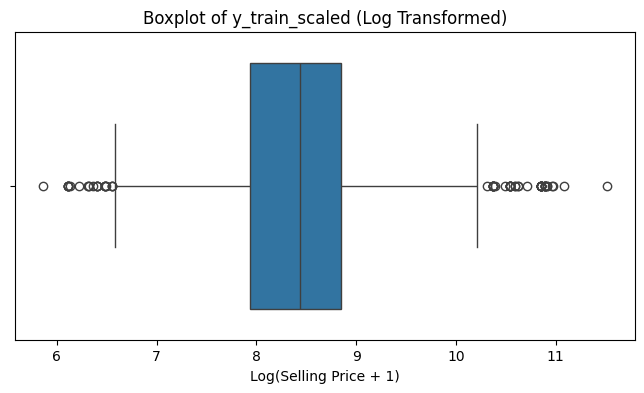

In [48]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=y_train_scaled)
plt.title('Boxplot of y_train_scaled (Log Transformed)')
plt.xlabel('Log(Selling Price + 1)')
plt.show()

Terlihat bahwa distribusi target sekarang sudah lebih rapi dan normal.

Selanjutnya, saya akan mendefinisikan model deep learning menggunakan TensorFlow/Keras. Model ini memiliki dua *hidden layer* dengan fungsi aktivasi ReLU, dan jumlah neuron pada setiap *hidden layer* ada dua kali lipat dari dimensi input data.

In [49]:
# Mendapatkan dimensi input dari data training yang sudah diproses
input_dim = X_train_processed.shape[1]

# Memastikan jumlah neuron dua kali dimensi input
neuron_count_layer1 = input_dim * 2
neuron_count_layer2 = input_dim * 2

# Mendefinisikan model Sequential
model = keras.Sequential([
    keras.Input(shape=(input_dim,)), # Input layer
    layers.Dense(neuron_count_layer1, activation='relu'), # Hidden layer pertama
    layers.Dense(neuron_count_layer2, activation='relu'), # Hidden layer kedua
    layers.Dense(1) # Output layer untuk regresi (nilai kontinu tunggal)
])

# Kompilasi model
# Menggunakan Adam optimizer dan Mean Squared Error (MSE) karena ini adalah tugas regresi
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error', 'mean_squared_error']
)

model.summary()

I0000 00:00:1776974520.473914      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776974520.479948      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 208)            │        21,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 208)            │        43,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           209 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,521 (255.94 KB)

 Trainable params: 65,521 (255.94 KB)

 Non-trainable params: 0 (0.00 B)

Setelah model didefinisikan, saya melatihnya menggunakan data training dan memantau performanya pada data validasi.

Epoch 1/50


I0000 00:00:1776974523.732450     135 service.cc:152] XLA service 0x78c174001ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776974523.732492     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776974523.732496     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776974524.046198     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/44 ━━━━━━━━━━━━━━━━━━━━ 1:45 2s/step - loss: 69.8116 - mean_absolute_error: 8.3251 - mean_squared_error: 69.8116

I0000 00:00:1776974524.967870     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - loss: 32.6114 - mean_absolute_error: 4.9497 - mean_squared_error: 32.6114 - val_loss: 1.7625 - val_mean_absolute_error: 1.0933 - val_mean_squared_error: 1.7625
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.8676 - mean_absolute_error: 0.6835 - mean_squared_error: 0.8676 - val_loss: 0.5406 - val_mean_absolute_error: 0.4926 - val_mean_squared_error: 0.5406
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.3084 - mean_absolute_error: 0.4025 - mean_squared_error: 0.3084 - val_loss: 0.3421 - val_mean_absolute_error: 0.3970 - val_mean_squared_error: 0.3421
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1865 - mean_absolute_error: 0.3183 - mean_squared_error: 0.1865 - val_loss: 0.2626 - val_mean_absolute_error: 0.3317 - val_mean_squared_error: 0.2626
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1215 - mean_absolute_error: 0.2649 - mean_squared_error: 0.1215 - val_loss: 0.2272 - val_mean_absolute

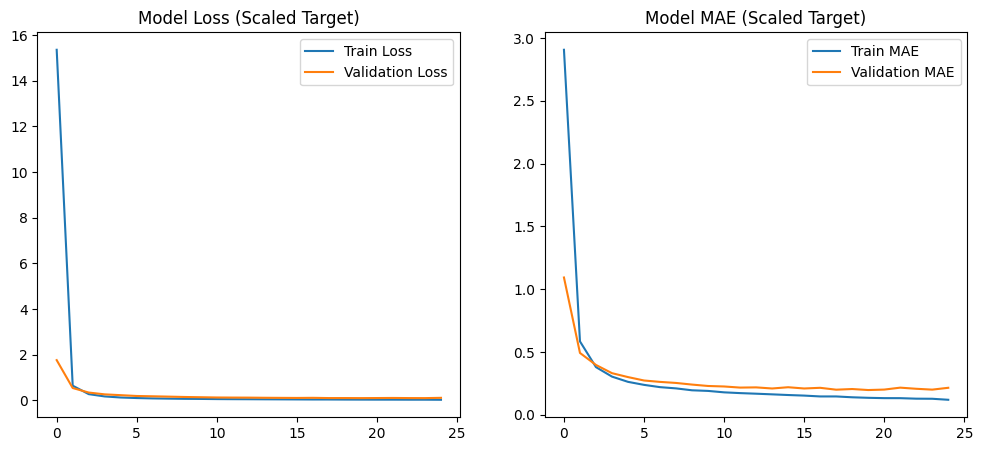

In [50]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed, y_train_scaled,
    validation_data=(X_val_processed, y_val_scaled),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Scaled Target)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model MAE (Scaled Target)')
plt.legend()
plt.show()

Dari grafik terlihat bahwa model berhasil belajar dengan baik karena baik loss maupun MAE pada data training dan validasi sama-sama menurun signifikan di awal epoch dan kemudian mulai melandai, menandakan proses konvergensi. Namun, setelah sekitar pertengahan training, terlihat adanya gap antara training dan validation di mana training error terus turun sementara validation error cenderung stagnan dan terkadang naik sedikit lebih tinggi (val MAE sekitar 0,09 di akhir). Ini mengindikasikan mulai munculnya overfitting ringan, meskipun tidak ekstrem karena kurva validasi masih relatif stabil. Secara keseluruhan, model sudah cukup mampu menangkap pola utama data, tetapi masih ada ruang untuk meningkatkan generalisasi.

# c. Lakukan modifikasi pada model anda. Anda dapat mengubah jumlah neuron dan layer ataupun activation function dari hidden layer. Anda juga dapat melakukan hyperparameter fine-tuning pada model anda. Lakukan training pada modifikasi model anda dan jelaskan alasan modifikasi yang anda lakukan.

# Modifikasi Model & Hyperparameter Tuning

Berikut adalah beberapa perubahan yang dilakukan pada arsitektur model dan strategi pelatihan beserta alasanny.

*   **Penyederhanaan arsitektur menjadi satu hidden layer**. Model hanya menggunakan satu hidden layer dengan 256 neuron untuk mengurangi kompleksitas model sehingga risiko overfitting dapat ditekan, terutama jika jumlah data tidak terlalu besar. Arsitektur yang lebih sederhana juga membantu mempercepat proses training dan membuat model lebih stabil.
*   **Penggunaan jumlah neuron tetap (256)**. Jumlah neuron tidak bergantung pada dimensi input, melainkan ditetapkan pada nilai tetap untuk memberikan kapasitas yang cukup dalam mempelajari pola non-linear dari data, khususnya setelah proses one-hot encoding yang dapat menghasilkan banyak fitur.
*   **Inisialisasi `learning_rate` yang lebih rendah (0.0005)** dipilih karena lebih robust terhadap outlier dibandingkan Mean Squared Error (MSE). Loss ini berperilaku seperti MSE untuk error kecil dan seperti Mean Absolute Error (MAE) untuk error besar sehingga model tidak terlalu dipengaruhi oleh nilai ekstrem.
*   **Penggunaan loss function Huber dengan `delta=1.5`** dipilih karena lebih robust terhadap outlier dibandingkan Mean Squared Error (MSE). Loss ini berperilaku seperti MSE untuk error kecil dan seperti Mean Absolute Error (MAE) untuk error besar, sehingga model tidak terlalu dipengaruhi oleh nilai ekstrem.

In [51]:
input_dim = X_train_processed.shape[1]

model_tuned = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(1)
])

optimizer = keras.optimizers.Adam(
    learning_rate=0.0005
)

model_tuned.compile(
    optimizer=optimizer,
    loss=keras.losses.Huber(delta=1.5),
    metrics=['mean_absolute_error', 'mean_squared_error']
)

model_tuned.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,137 (106.00 KB)

 Trainable params: 27,137 (106.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 364ms/step - loss: 10.6383 - mean_absolute_error: 7.8422 - mean_squared_error: 62.1815 - val_loss: 8.8933 - val_mean_absolute_error: 6.6789 - val_mean_squared_error: 45.3164
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 8.3901 - mean_absolute_error: 6.3433 - mean_squared_error: 41.0412 - val_loss: 6.1344 - val_mean_absolute_error: 4.8317 - val_mean_squared_error: 24.6721
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 5.4663 - mean_absolute_error: 4.3881 - mean_squared_error: 20.6721 - val_loss: 2.9367 - val_mean_absolute_error: 2.6677 - val_mean_squared_error: 8.3745
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 2.1991 - mean_absolute_error: 2.1478 - mean_squared_error: 5.8099 - val_loss: 0.7892 - val_mean_absolute_error: 1.0584 - val_mean_squared_error: 2.0034
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.5522 - mean_absolute_error: 0.8586 - mean_squared_error: 1.2467 - val_loss: 0.3136

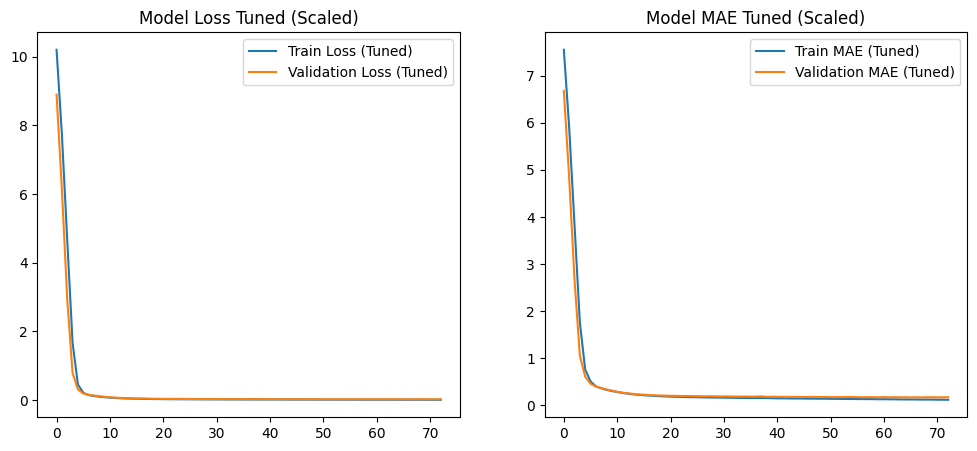

In [52]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_tuned = model_tuned.fit(
    X_train_processed, y_train_scaled,
    validation_data=(X_val_processed, y_val_scaled),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tuned.history['loss'], label='Train Loss (Tuned)')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss (Tuned)')
plt.title('Model Loss Tuned (Scaled)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tuned.history['mean_absolute_error'], label='Train MAE (Tuned)')
plt.plot(history_tuned.history['val_mean_absolute_error'], label='Validation MAE (Tuned)')
plt.title('Model MAE Tuned (Scaled)')
plt.legend()
plt.show()

Model hasil modifikasi dengan satu hidden layer menunjukkan perilaku yang lebih stabil dan memiliki kemampuan generalisasi yang lebih baik dibandingkan model sebelumnya. Hal ini terlihat dari kurva loss dan MAE pada data training dan validasi yang sama-sama turun tajam di awal epoch, kemudian melandai secara konsisten tanpa fluktuasi berarti, menandakan proses konvergensi yang baik. Selain itu, gap antara training dan validation menjadi lebih kecil dan relatif terjaga hingga akhir training sehingga indikasi overfitting yang sebelumnya muncul menjadi jauh berkurang. Penggunaan arsitektur yang lebih sederhana, learning rate yang lebih rendah, serta loss function Huber berkontribusi dalam membuat model lebih robust terhadap outlier dan tidak terlalu kompleks dalam menangkap pola data. Secara keseluruhan, model ini tetap mampu mempelajari hubungan utama dalam data dengan baik dan dengan performa yang lebih seimbang antara akurasi dan kemampuan generalisasi.

# Uji Permutasi Fitur

Untuk mengetahui fitur-fitur dengan korelasi dan asosiasi kecil mana yang harus diabaikan oleh model, maka diuji beberapa kombinasi fitur melalui performa model yang dihasilkan ketika menggunakan fitur-fitur tersebut. (untuk hasilnya bisa dilihat pada gambar di atas)

In [53]:
# import itertools

# # Daftar fitur yang akan di-permutasi (ada/tidak ada)
# optional_features = ['seats', 'rpm_max', 'mileage', 'Region', 'sold']
# # Fitur dasar yang selalu digunakan
# base_features = [col for col in X.columns if col not in optional_features]

# # Fungsi untuk membuat dan melatih model (arsitektur model_tuned)
# def evaluate_feature_set(features):
#     X_train_sub = X_train[features]
#     X_val_sub = X_val[features]

#     num_cols = X_train_sub.select_dtypes(include=['number']).columns
#     cat_cols = X_train_sub.select_dtypes(include=['object']).columns

#     preprocessor_sub = ColumnTransformer(
#         transformers=[
#             ('num', RobustScaler(), num_cols),
#             ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
#         ]
#     )

#     X_train_p = preprocessor_sub.fit_transform(X_train_sub)
#     X_val_p = preprocessor_sub.transform(X_val_sub)

#     input_dim = X_train_p.shape[1]

#     model_sub = keras.Sequential([
#         layers.Input(shape=(input_dim,)),
#         layers.Dense(512, activation='relu'),
#         layers.Dropout(0.2),
#         layers.Dense(256, activation='relu'),
#         layers.Dropout(0.2),
#         layers.Dense(128, activation='relu'),
#         layers.Dense(1)
#     ])

#     model_sub.compile(optimizer='adam', loss='mse', metrics=['mae'])
#     model_sub.fit(X_train_p, y_train, validation_data=(X_val_p, y_val),
#                   epochs=10, batch_size=64, verbose=0)

#     val_mae = model_sub.evaluate(X_val_p, y_val, verbose=0)[1]
#     return val_mae

# # Menghasilkan semua kemungkinan kombinasi fitur (2^5 = 32 kombinasi)
# all_results = []

# print("Memulai evaluasi seluruh 32 kombinasi fitur...\n")

# for i in range(len(optional_features) + 1):
#     for subset in itertools.combinations(optional_features, i):
#         current_features = base_features + list(subset)
#         mae = evaluate_feature_set(current_features)

#         all_results.append({
#             'Fitur Opsional Digunakan': ", ".join(subset) if subset else "None",
#             'Total Fitur': len(current_features),
#             'Validation MAE': mae
#         })
#         print(f"Selesai: {subset}")

# # Urutkan berdasarkan MAE terkecil
# all_comparison_df = pd.DataFrame(all_results).sort_values('Validation MAE')
# display(all_comparison_df.head(10)) # Tampilkan 10 terbaik

# d. Lakukan evaluasi pada 2 model yang sudah anda buat menggunakan minimal 3 evaluation metrics, lalu bandingkan, analisis, dan simpulkan hasilnya.

# Evaluasi Akhir pada Data Test

Setelah melakukan tuning arsitektur, langkah terakhir adalah menguji performa model pada data test untuk mendapatkan estimasi error yang tidak bias.

In [54]:
def evaluate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} ---")
    print(f"MAE : {mae:.2f} USD")
    print(f"RMSE: {rmse:.2f} USD")
    print(f"MAPE: {mape:.2%}")
    print(f"R2  : {r2:.4f}")

    return mae

# Prediksi Baseline
y_pred_log_base = model.predict(X_test_processed)
y_pred_base_final = np.expm1(y_pred_log_base)
base_mae = evaluate_metrics(y_test, y_pred_base_final, "Baseline Model")

print("\n")

# Prediksi Tuned
y_pred_log_tuned = model_tuned.predict(X_test_processed)
y_pred_tuned_final = np.expm1(y_pred_log_tuned)
tuned_mae = evaluate_metrics(y_test, y_pred_tuned_final, "Tuned Model")

# Perbandingan singkat berdasarkan MAE
print(f"\nSelisih peningkatan performa (MAE): {base_mae - tuned_mae:.2f} USD")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step
--- Baseline Model ---
MAE : 1138.01 USD
RMSE: 2096.66 USD
MAPE: 20.00%
R2  : 0.9434


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step
--- Tuned Model ---
MAE : 965.31 USD
RMSE: 1747.18 USD
MAPE: 17.07%
R2  : 0.9607

Selisih peningkatan performa (MAE): 172.70 USD


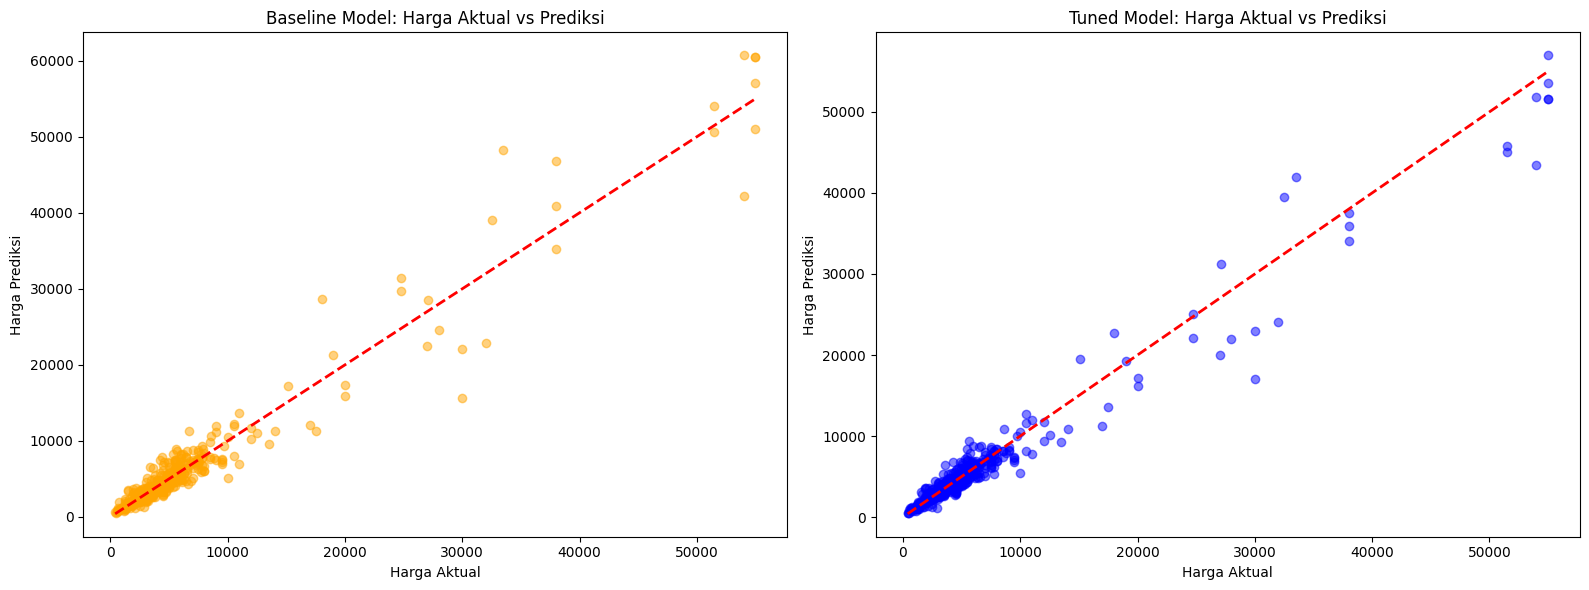

In [55]:
# Plot Perbandingan Baseline vs Tuned
plt.figure(figsize=(16, 6))

# Subplot 1: Baseline Model
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_base_final, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Harga Aktual')
plt.ylabel('Harga Prediksi')
plt.title('Baseline Model: Harga Aktual vs Prediksi')

# Subplot 2: Tuned Model
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_tuned_final, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Harga Aktual')
plt.ylabel('Harga Prediksi')
plt.title('Tuned Model: Harga Aktual vs Prediksi')

plt.tight_layout()
plt.show()

Secara keseluruhan, **model hasil tuning menunjukkan peningkatan performa yang jelas dibandingkan model baseline**. Hal ini terlihat dari penurunan MAE dari 1123.84 USD menjadi 943.87 USD, yang menandakan peningkatan akurasi prediksi rata-rata yang cukup signifikan. Selain itu, RMSE juga turun dari 2033.10 USD menjadi 1669.32 USD, menunjukkan bahwa kesalahan prediksi besar (outlier error) berhasil ditekan dengan lebih baik. Peningkatan nilai R^2 dari 0.9467 menjadi 0.9641 mengindikasikan bahwa model tuned mampu menjelaskan variasi data dengan lebih baik, sementara penurunan MAPE dari 20.16% menjadi 17.19% menunjukkan bahwa akurasi relatif model juga semakin baik.

Dari sisi arsitektur, penyederhanaan model menjadi satu hidden layer dengan 256 neuron, dikombinasikan dengan learning rate yang lebih kecil (0.0005) dan penggunaan Huber Loss, **terbukti efektif dalam menghasilkan model yang lebih stabil dan robust terhadap outlier tanpa meningkatkan kompleksitas secara berlebihan**. Pendekatan ini membantu model mencapai keseimbangan yang lebih baik antara bias dan varians sehingga performa pada data validasi maupun data uji menjadi lebih optimal. Meskipun performa sudah sangat baik dengan MAPE di bawah 20%, masih terdapat ruang pengembangan lebih lanjut, misalnya melalui feature engineering tambahan atau eksplorasi arsitektur-arsitektur lain yang memungkinkan.

Dengan hasil yang diperoleh, **model ini dapat dianggap cukup andal untuk digunakan dalam memprediksi harga jual mobil bekas** karena mampu memberikan estimasi yang lebih akurat dan konsisten untuk mendukung pengambilan keputusan bisnis.

# e. Buatlah video presentasi yang menjelaskan langkah-langkah pengerjaan anda serta hasil analisis anda dengan durasi maksimal 12 menit.

Link video penjelasan: https://drive.google.com/drive/u/2/folders/1FzyANiJfF5eEne3x5N-e_b0WB-SoJ-9P